## 1. Imports and setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

## 2. Load data and build the return series

Instead of feeding raw price windows into the models and asking them to
predict the next raw price, we work in **return space**: `returns[t] = (price[t+1] - price[t]) / price[t]`.
Returns don't have a permanent trend the way price does, so a model trained on historical returns
doesn't need to extrapolate beyond anything it has seen — a +2% day looks the same whether gold is at
\$300 or \$5,000.

In [ ]:
df = pd.read_csv('Gold.csv')
data = df['final_price'].values.astype(float)
n = len(data)
print(f"Total data points: {n}")

WINDOW = 260          # one year of data
TRAIN_RATIO = 0.8
train_size = int(n * TRAIN_RATIO)
test_size = n - train_size
print(f"Train size: {train_size}, Test size: {test_size}")

FUTURE_STEPS = 1500

# Day-over-day returns - a stationary series, unlike the raw price level
returns = np.diff(data) / data[:-1]
train_size_r = train_size - 1   # returns series is 1 shorter than the price series

Total data points: 6391
Train size: 5112, Test size: 1279


## 3. Helper functions

In [ ]:
def create_sequences(series, window):
    """Convert a time series into (X, y) sliding-window samples."""
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i])
        y.append(series[i])
    return np.array(X), np.array(y)

def forecast_recursive(model, last_window, steps, scaler=None):
    """Recursively forecast future RETURNS (not prices)."""
    predictions = []
    current_window = last_window.copy()
    for _ in range(steps):
        X_input = current_window.reshape(1, -1)
        if scaler is not None:
            X_input = scaler.transform(X_input)
        pred = model.predict(X_input)[0]
        predictions.append(pred)
        current_window = np.roll(current_window, -1)
        current_window[-1] = pred
    return np.array(predictions)

def returns_to_prices(last_price, pred_returns):
    """Compound a sequence of predicted returns onto a starting price."""
    prices = np.empty(len(pred_returns))
    prev = last_price
    for i, r in enumerate(pred_returns):
        prev = prev * (1.0 + r)
        prices[i] = prev
    return prices

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")
    return rmse, mae

def plot_results(name, train_data, test_data, test_pred, forecast, forecast_steps):
    """Plot training, test actual, test predicted, and future forecast (all in price terms)."""
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(train_data)), train_data, label='Training Data', color='blue')
    test_start = len(train_data)
    test_end = test_start + len(test_data)
    plt.plot(range(test_start, test_end), test_data, label='Test Actual', color='green')
    plt.plot(range(test_start, test_end), test_pred, label='Test Predicted', linestyle='--', color='orange')
    future_start = test_end
    future_end = future_start + forecast_steps
    plt.plot(range(future_start, future_end), forecast, label='Future Forecast', linestyle='-.', color='red')
    plt.title(f'{name} - Gold Price Forecast')
    plt.xlabel('Time Step')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

## 4. Build train/test samples in return space

In [ ]:
X_full, y_full = create_sequences(returns, WINDOW)
X_train = X_full[:train_size_r - WINDOW]
y_train = y_full[:train_size_r - WINDOW]          # returns
X_test = X_full[train_size_r - WINDOW:]
y_test = y_full[train_size_r - WINDOW:]           # returns

print(f"ML training samples: {X_train.shape[0]}, test samples: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Seed for the recursive future forecast: the last WINDOW known returns
last_window = returns[-WINDOW:].copy()
last_known_price = data[-1]

# True prices needed to convert predicted returns back into predicted prices
offset = train_size_r - WINDOW
test_prev_prices = data[WINDOW+offset : WINDOW+offset+len(y_test)]
test_actual_prices = data[WINDOW+offset+1 : WINDOW+offset+1+len(y_test)]

ML training samples: 4851, test samples: 1279


## 5. Train, evaluate, and forecast with each ML model


--- Training Random Forest ---


Random Forest        | RMSE: 38.95 | MAE: 21.37 | R2: 0.9980


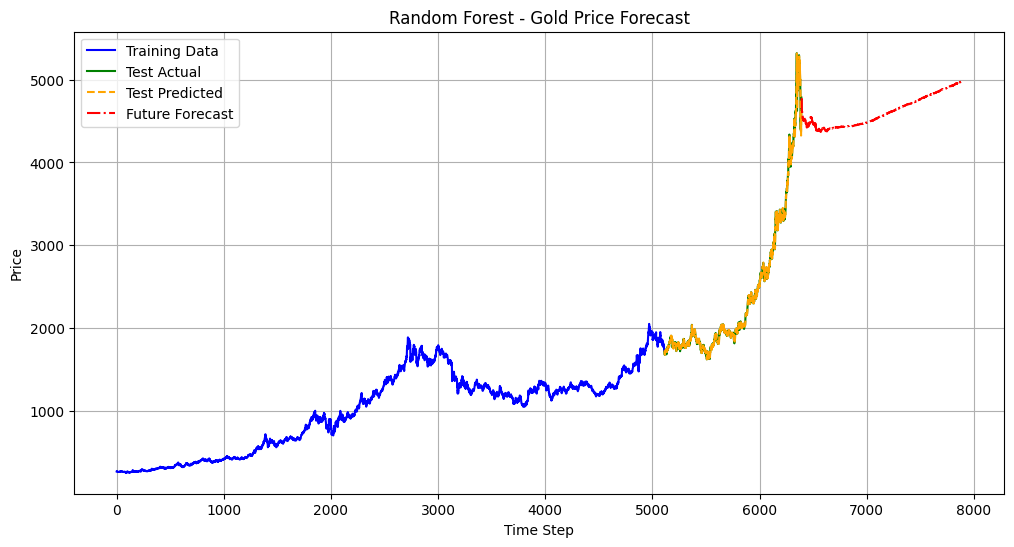


--- Training Linear Regression ---


Linear Regression    | RMSE: 39.37 | MAE: 21.88 | R2: 0.9979


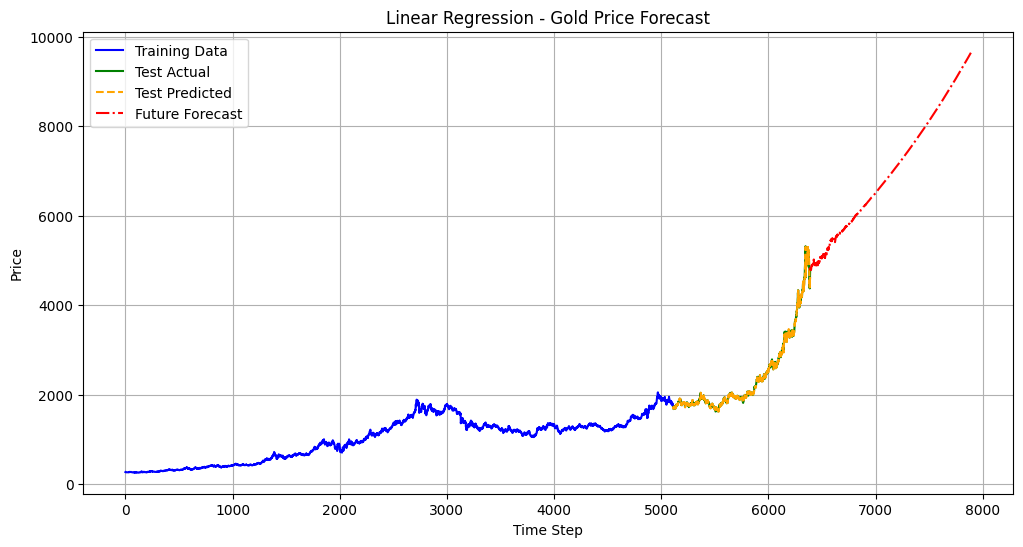


--- Training Decision Tree ---


Decision Tree        | RMSE: 53.38 | MAE: 31.11 | R2: 0.9962


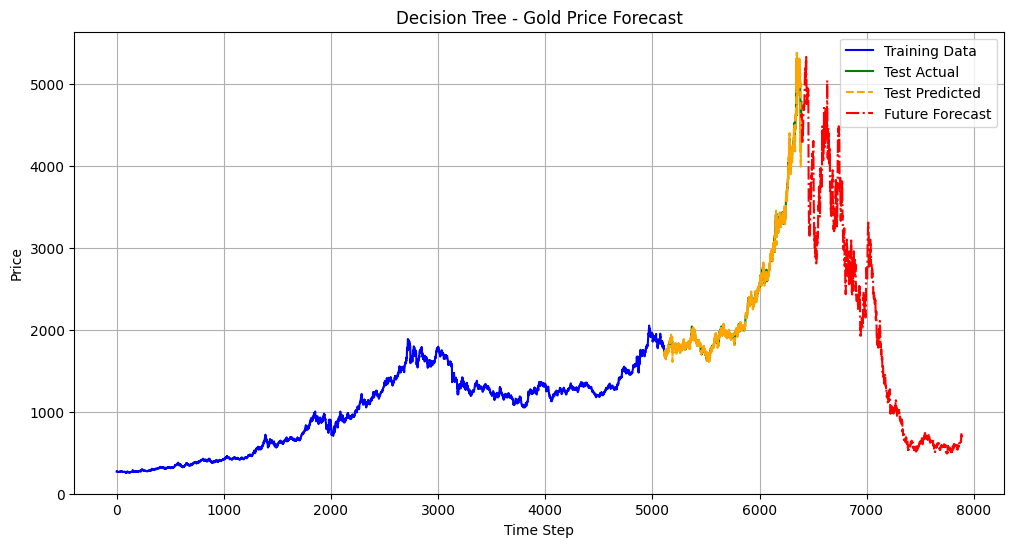


--- Training XGBoost ---


XGBoost              | RMSE: 41.05 | MAE: 23.49 | R2: 0.9977


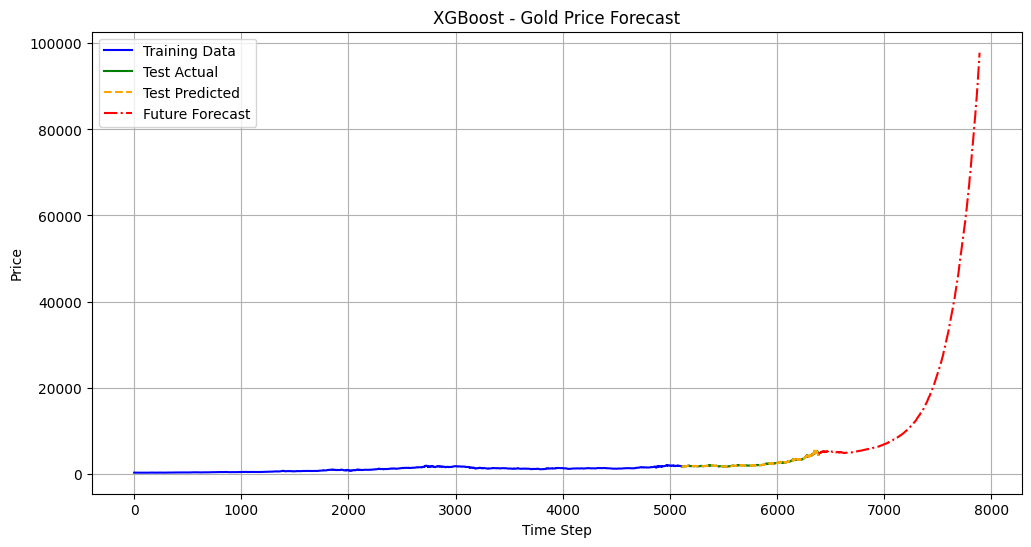


--- Training SVR ---


SVR                  | RMSE: 39.32 | MAE: 22.06 | R2: 0.9979


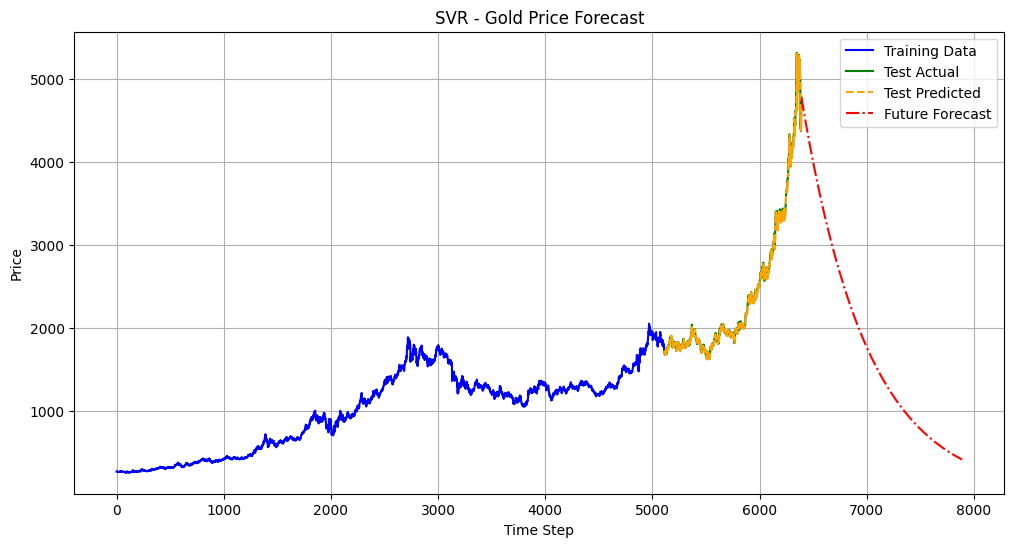


--- Training KNN ---


KNN                  | RMSE: 39.95 | MAE: 22.38 | R2: 0.9979


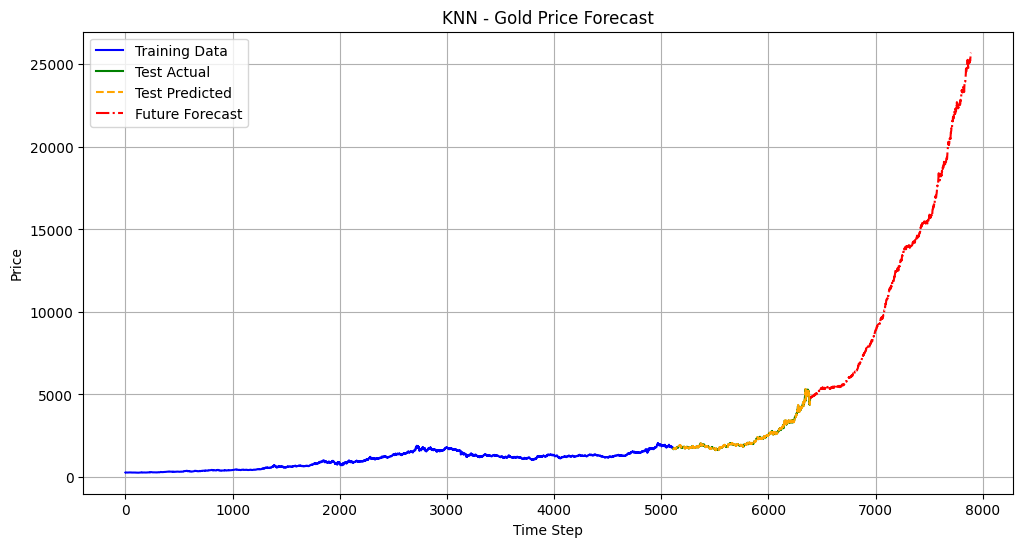

In [ ]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    if name in ['SVR', 'KNN', 'Linear Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred_returns = model.predict(X_test_scaled)
        pred_return_forecast = forecast_recursive(model, last_window, FUTURE_STEPS, scaler=scaler)
    else:
        model.fit(X_train, y_train)
        y_pred_returns = model.predict(X_test)
        pred_return_forecast = forecast_recursive(model, last_window, FUTURE_STEPS, scaler=None)

    # Convert predicted RETURNS back to predicted PRICES
    y_pred_prices = test_prev_prices * (1.0 + y_pred_returns)
    price_forecast = returns_to_prices(last_known_price, pred_return_forecast)

    rmse, mae = evaluate_model(name, test_actual_prices, y_pred_prices)
    results[name] = {'rmse': rmse, 'mae': mae, 'forecast': price_forecast}

    plot_results(name, data[:train_size], data[train_size:], y_pred_prices, price_forecast, FUTURE_STEPS)

## 6. ARIMA (statistical baseline)

Fixed to use a **non-seasonal** `auto_arima` search. The differencing term (`d=1`) already accounts
for the trend; searching seasonal orders with `m=260` (as in the original notebook) is what was
almost certainly causing that cell to hang.


--- Training ARIMA ---


Auto ARIMA selected order: (3, 1, 2)


ARIMA                      | RMSE: 1097.99 | MAE: 685.03


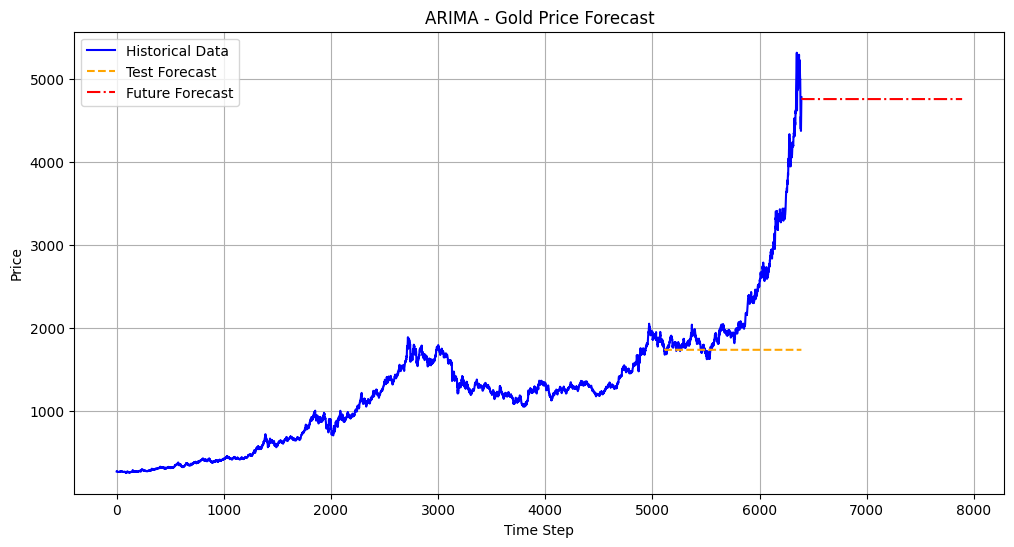

In [ ]:
print("\n--- Training ARIMA ---")
train_series = data[:train_size]
test_series = data[train_size:]

try:
    from pmdarima import auto_arima
    auto_model = auto_arima(train_series, seasonal=False,
                            stepwise=True, trace=False, error_action='ignore', suppress_warnings=True)
    order = auto_model.order
    print(f"Auto ARIMA selected order: {order}")
except ImportError:
    print("pmdarima not installed, using fixed ARIMA(5,1,0)")
    order = (5, 1, 0)

arima_model = ARIMA(train_series, order=order)
arima_fit = arima_model.fit()

test_forecast = arima_fit.forecast(steps=len(test_series))
rmse_arima = np.sqrt(mean_squared_error(test_series, test_forecast))
mae_arima = mean_absolute_error(test_series, test_forecast)
print(f"ARIMA {'':20} | RMSE: {rmse_arima:.2f} | MAE: {mae_arima:.2f}")
results['ARIMA'] = {'rmse': rmse_arima, 'mae': mae_arima}

# Retrain on full data for the true future forecast
arima_full = ARIMA(data, order=order)
arima_full_fit = arima_full.fit()
future_forecast = arima_full_fit.forecast(steps=FUTURE_STEPS)

plt.figure(figsize=(12, 6))
plt.plot(range(len(data)), data, label='Historical Data', color='blue')
test_start = train_size
test_end = train_size + len(test_series)
plt.plot(range(test_start, test_end), test_forecast, label='Test Forecast', linestyle='--', color='orange')
future_start = test_end
future_end = future_start + FUTURE_STEPS
plt.plot(range(future_start, future_end), future_forecast, label='Future Forecast', linestyle='-.', color='red')
plt.title('ARIMA - Gold Price Forecast')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

**Note:** ARIMA's `.forecast(steps=N)` produces one *multi-step* forecast in a single shot (it isn't
re-given the true intervening prices the way the ML models above are in the test-set evaluation), and
a plain ARIMA point forecast with no drift term converges toward a flat line over a long horizon. That
mismatch with the ML models' one-step-ahead test evaluation is a pre-existing property of how the
notebook compares ARIMA to the ML models, not something introduced by this fix. If you want ARIMA's
long-horizon forecast to keep trending, add a drift/trend term, e.g. `ARIMA(train_series, order=order,
trend='t')`.

## 7. Summary and save forecasts

In [ ]:
print("\n--- Model Performance Summary ---")
print(f"{'Model':20} | {'RMSE':>8} | {'MAE':>8}")
for name, metrics in results.items():
    print(f"{name:20} | {metrics['rmse']:8.2f} | {metrics['mae']:8.2f}")

forecast_df = pd.DataFrame({
    'Step': np.arange(1, FUTURE_STEPS+1),
    **{f'{name}_forecast': results[name]['forecast'] for name in models.keys() if 'forecast' in results[name]},
    'ARIMA_forecast': future_forecast
})
forecast_df.to_csv('gold_forecast_next_1500.csv', index=False)
print("\nForecasts saved to 'gold_forecast_next_1500.csv'")


--- Model Performance Summary ---
Model                |     RMSE |      MAE
Random Forest        |    38.95 |    21.37
Linear Regression    |    39.37 |    21.88
Decision Tree        |    53.38 |    31.11
XGBoost              |    41.05 |    23.49
SVR                  |    39.32 |    22.06
KNN                  |    39.95 |    22.38
ARIMA                |  1097.99 |   685.03

Forecasts saved to 'gold_forecast_next_1500.csv'
